<a href="https://colab.research.google.com/github/paulogkl/projeto-integrador-7-trimestre/blob/main/CERTO_projeto_integrador_7_trimestre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# importação e Carregamento
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# carregando a base "Tips.csv"
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

print("5 primeiras linhas")
display(df.head())

5 primeiras linhas


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [11]:
# traduzindo a base de dados, deixando em português
# traduzindo nomes das colunas
df = df.rename(columns={
    'total_bill': 'valor_conta',
    'tip': 'gorjeta',
    'sex': 'sexo',
    'smoker': 'fumante',
    'day': 'dia_semana',
    'time': 'periodo',
    'size': 'tamanho_mesa'
})

# convertendo valores para Reais (cotação fictícia de R$ 5,00)
cotacao_dolar = 5.00
df['valor_conta'] = (df['valor_conta'] * cotacao_dolar).round(2)
df['gorjeta'] = (df['gorjeta'] * cotacao_dolar).round(2)

# traduzindo os valores das categorias
df['sexo'] = df['sexo'].replace({'Male': 'Masculino', 'Female': 'Feminino'})
df['fumante'] = df['fumante'].replace({'Yes': 'Sim', 'No': 'Não'})
df['dia_semana'] = df['dia_semana'].replace({
    'Thur': 'Quinta', 'Fri': 'Sexta', 'Sat': 'Sábado', 'Sun': 'Domingo'
})
df['periodo'] = df['periodo'].replace({'Lunch': 'Almoço', 'Dinner': 'Jantar'})

print("base em português")
display(df.head())

Base em português


,valor_conta,gorjeta,sexo,fumante,dia_semana,periodo,tamanho_mesa
0,84.95,5.05,Feminino,Não,Domingo,Jantar,2
1,51.70,8.30,Masculino,Não,Domingo,Jantar,3
2,105.05,17.50,Masculino,Não,Domingo,Jantar,3
3,118.40,16.55,Masculino,Não,Domingo,Jantar,2
4,122.95,18.05,Feminino,Não,Domingo,Jantar,4


In [12]:
# análise exploratória de dados
print("Estatísticas Descritivas")
display(df.describe())

print("\n Média da conta por dia da semana")
media_por_dia = df.groupby('dia_semana')['valor_conta'].mean().sort_values(ascending=False)
display(media_por_dia)

print("\n Média de gorjeta por sexo")
media_gorjeta_sexo = df.groupby('sexo')['gorjeta'].mean()
display(media_gorjeta_sexo)

print("\n Há dados nulos?")
print(df.isnull().sum())

Estatísticas Descritivas


,valor_conta,gorjeta,tamanho_mesa
count,244.000000,244.000000,244.000000
mean,98.929713,14.991393,2.569672
std,44.512060,6.918191,0.951100
min,15.350000,5.000000,1.000000
25%,66.737500,10.000000,2.000000
50%,88.975000,14.500000,2.000000
75%,120.637500,17.812500,3.000000
max,254.050000,50.000000,6.000000



 Média da conta por dia da semana


,valor_conta
dia_semana,
Domingo,107.050000
Sábado,102.206897
Quinta,88.413710
Sexta,85.757895



 Média de gorjeta por sexo


,gorjeta
sexo,
Feminino,14.167241
Masculino,15.448089



 Há dados nulos?
valor_conta     0
gorjeta         0
sexo            0
fumante         0
dia_semana      0
periodo         0
tamanho_mesa    0
dtype: int64


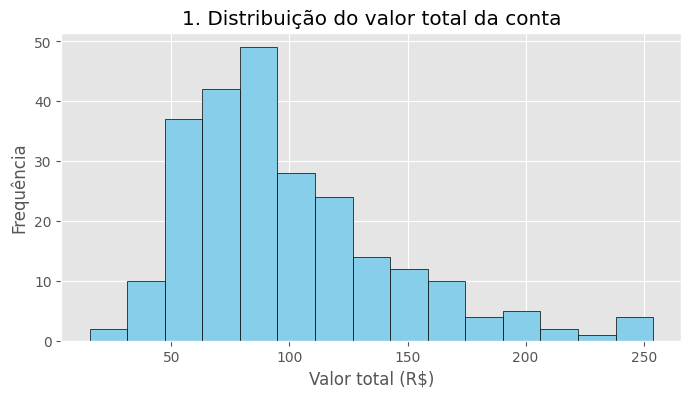

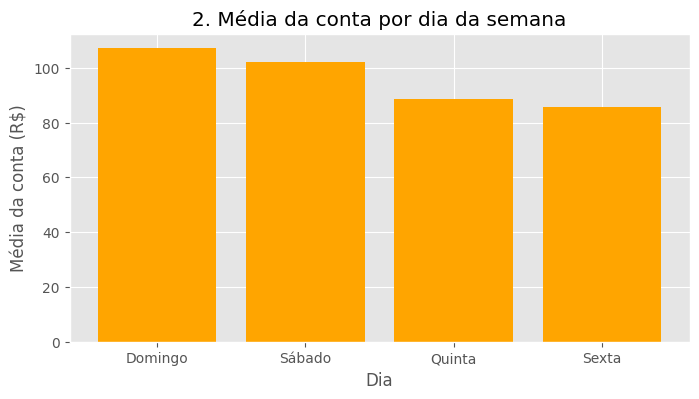

<Figure size 800x400 with 0 Axes>

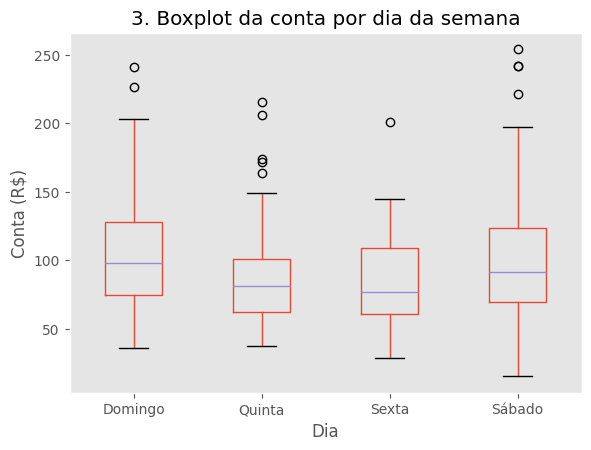

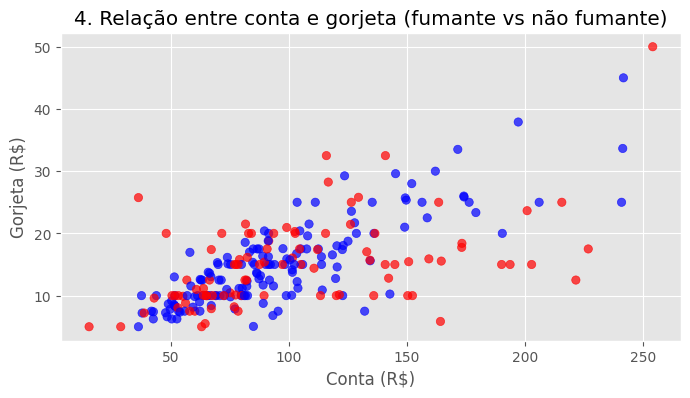

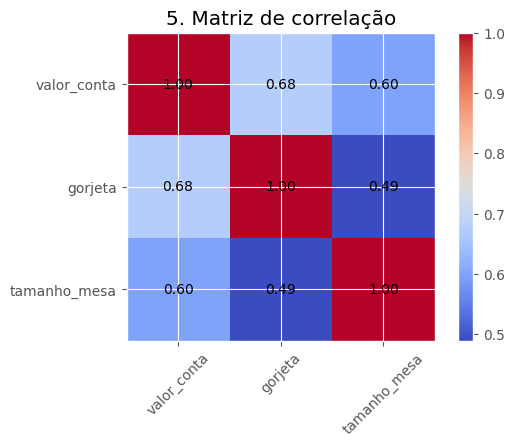

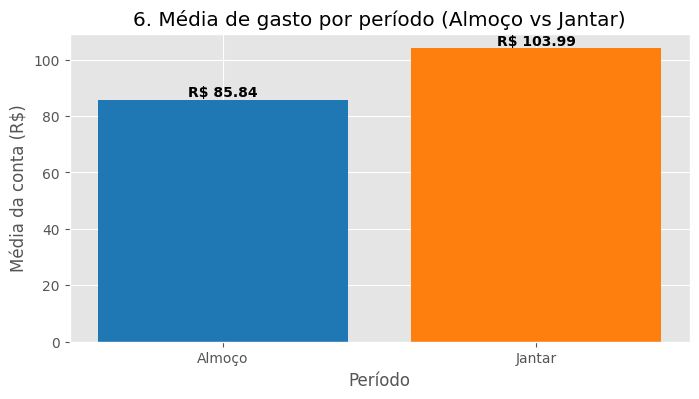

In [16]:
# Visualizações
plt.style.use('ggplot')

# Histograma
plt.figure(figsize=(8,4))
plt.hist(df['valor_conta'], bins=15, color='skyblue', edgecolor='black')
plt.title('1. Distribuição do valor total da conta')
plt.xlabel('Valor total (R$)')
plt.ylabel('Frequência')
plt.show()

# Gráfico de barras
plt.figure(figsize=(8,4))
plt.bar(media_por_dia.index, media_por_dia.values, color='orange')
plt.title('2. Média da conta por dia da semana')
plt.xlabel('Dia')
plt.ylabel('Média da conta (R$)')
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
df.boxplot(column='valor_conta', by='dia_semana', grid=False)
plt.title('3. Boxplot da conta por dia da semana')
plt.suptitle('')
plt.xlabel('Dia')
plt.ylabel('Conta (R$)')
plt.show()

# Gráfico de dispersão
cores = df['fumante'].map({'Sim':'red', 'Não':'blue'})
plt.figure(figsize=(8,4))
plt.scatter(df['valor_conta'], df['gorjeta'], c=cores, alpha=0.7)
plt.title('4. Relação entre conta e gorjeta (fumante vs não fumante)')
plt.xlabel('Conta (R$)')
plt.ylabel('Gorjeta (R$)')
plt.show()

# Mapa de calor, correlação

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(6,4))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('5. Matriz de correlação')


for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()


# média de gasto por período (almoço vs jantar)
# calculando a média de gasto por período
media_periodo = df.groupby('periodo')['valor_conta'].mean()

plt.figure(figsize=(8,4))
# criando o gráfico de barras com cores diferentes para cada período
plt.bar(media_periodo.index, media_periodo.values, color=['#1f77b4', '#ff7f0e'])
plt.title('6. Média de gasto por período (Almoço vs Jantar)')
plt.xlabel('Período')
plt.ylabel('Média da conta (R$)')

# adicionando o valor exato em cima de cada barra para facilitar a leitura
for i, valor in enumerate(media_periodo.values):
    plt.text(i, valor + 1, f'R$ {valor:.2f}', ha='center', fontweight='bold')

plt.show()
